## **Data Preparation and Analysis**



In [ ]:
# Loading neccesary libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import  stats
import warnings
warnings.filterwarnings('ignore')
plt.style.use('default')

In [ ]:
%matplotlib inline
# without this the plots would be opened  in a new window (not browser)
# with this instruction plots will be included in the notebook

In [ ]:
# Use %config InlineBackend.figure_format = 'retina'
# after %matplotlib inline to render higher resolution images
%config InlineBackend.figure_format = 'retina'

In [ ]:
# If you wish to use Google colab, the following code will allow you to mount your Google Drive. Otherwise, comment on the following lines.
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# To print multiple outputs
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
# Set it to None to display all columns in the dataframe
pd.set_option('display.max_columns', None)

In [ ]:
#Reading the data from google drive
data=pd.read_csv('gdrive/MyDrive/WS4/ws4data/Video_Store.csv')

print("Data imported successfully")


Data imported successfully


**Task:** Explore the general characteristics of the data by computing the means and standard deviations of the numerical attributes and the distributions of male and female customers, the preferred movie genres, etc.


In [ ]:
#numerical
numerical_attributes = ['Income', 'Age', 'Rentals', 'Avg Per Visit']

for attribute in numerical_attributes:
  print(f"Attribute: {attribute}")
  print(f"Mean: {data[attribute].replace('[$,]', '', regex=True).astype(int).mean()}")                #mean
  print(f"Standard Deviation: {data[attribute].replace('[$,]', '', regex=True).astype(int).std()}\n") #standard deviation

#categorical
categorical_attributes = ['Gender', 'Incidentals', 'Genre']

for attribute in categorical_attributes:
  print(f"Attribute: {attribute}")
  print((data[attribute].value_counts(normalize=True)*100).astype(str)+'%')  #percentages
  print("\n")


Attribute: Income
Mean: 42300.0
Standard Deviation: 21409.753642216627

Attribute: Age
Mean: 31.56
Standard Deviation: 12.000272105758475

Attribute: Rentals
Mean: 26.24
Standard Deviation: 10.027635283941828

Attribute: Avg Per Visit
Mean: 2.28
Standard Deviation: 0.904410959505395

Attribute: Gender
Gender
M    52.0%
F    48.0%
Name: proportion, dtype: object


Attribute: Incidentals
Incidentals
Yes    52.0%
No     48.0%
Name: proportion, dtype: object


Attribute: Genre
Genre
Drama     40.0%
Action    36.0%
Comedy    24.0%
Name: proportion, dtype: object




**Task**:  Create a contingency table of the Genre variable with Gender.

In [ ]:
crosstab = pd.crosstab(data['Genre'], data['Gender']) #quantity
print(crosstab)

print("\n")

crosstab= round(crosstab.div(crosstab.sum(0), axis=1) * 100, 1) #percentage
print(crosstab)

Gender   F   M
Genre         
Action   5  13
Comedy   6   6
Drama   13   7


Gender     F     M
Genre             
Action  20.8  50.0
Comedy  25.0  23.1
Drama   54.2  26.9


**Task:** Create a horizontal bar graph of the Genre variable with a Gender overlay (stacked bar chart).



<Axes: ylabel='Genre'>

<Figure size 1400x800 with 0 Axes>

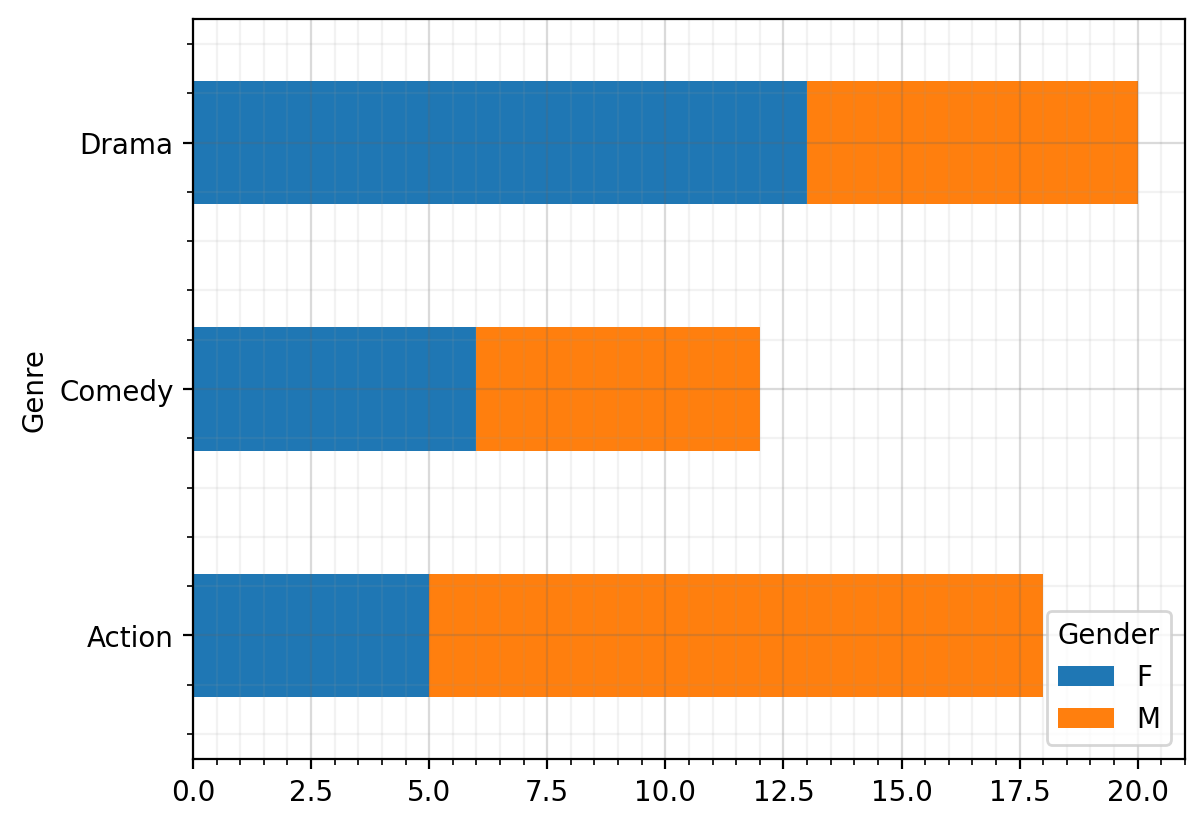

In [ ]:
fig = plt.figure(figsize=(14, 8))                         #figure size
crosstab = pd.crosstab(data['Genre'], data['Gender'])     #contingency table
crosstab.plot(kind='barh', stacked = True)
# Show the grid lines as dark grey lines
plt.grid(visible=True, which='major', color='#666666', linestyle='-',alpha=0.24)
# Show the minor grid lines with very faint and almost transparent grey lines
plt.minorticks_on()
plt.grid(visible=True, which='minor', color='#999999', linestyle='-',alpha=0.12)
plt.savefig("gdrive/MyDrive/WS4/ws4data/group_7_ws4_graph_1.jpg", bbox_inches='tight', dpi=300)
plt.show()

**Task:** Create a normalized horizontal bar graph of the Genre variable with Gender overlay (stacked bar chart).

<Axes: ylabel='Genre'>

<Figure size 1400x800 with 0 Axes>

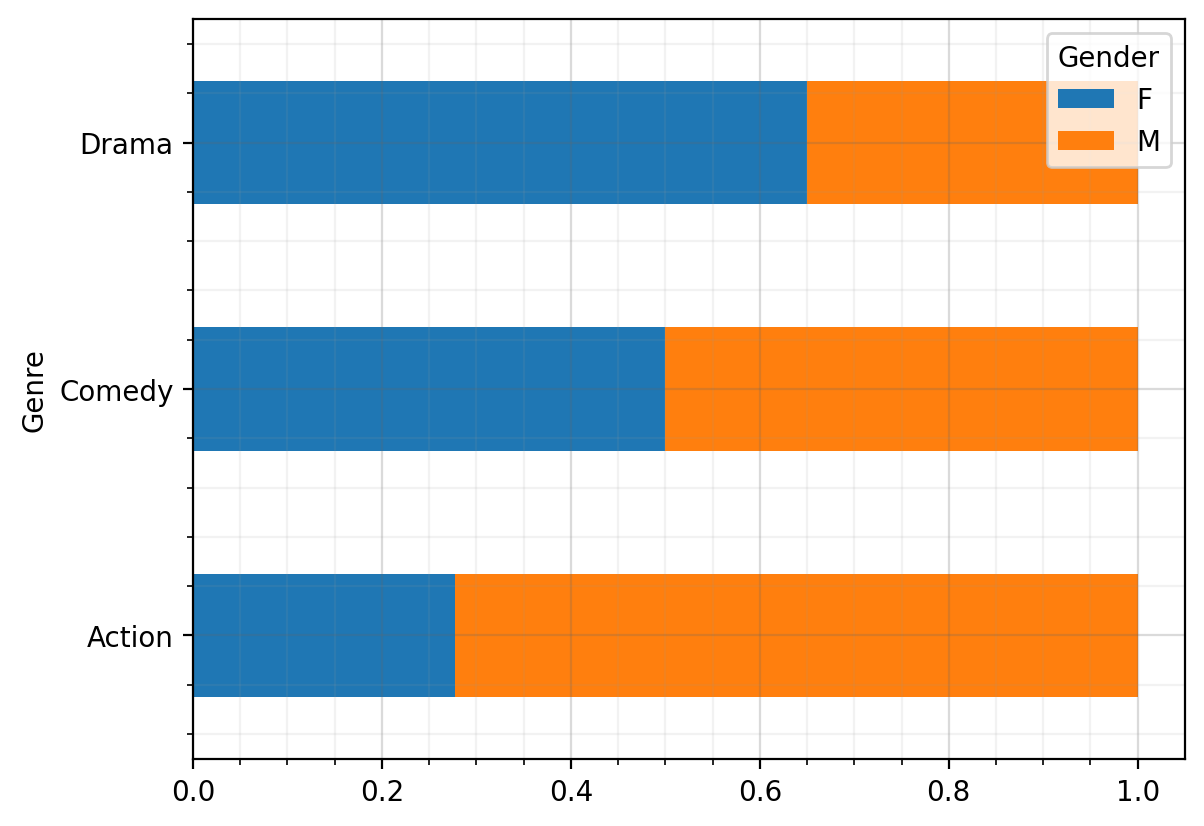

In [ ]:
crosstab = pd.crosstab(data['Genre'], data['Gender'])  #contingency table
crosstab_norm = crosstab.div(crosstab.sum(1), axis=0)  #normalize
fig = plt.figure(figsize=(14, 8))                      #figure size
crosstab_norm.plot(kind='barh', stacked=True)
# Show the grid lines as dark grey lines
plt.grid(visible=True,which='major', color='#666666', linestyle='-', alpha=0.24)
# Show the minor grid lines with very faint and almost transparent grey lines
plt.minorticks_on()
plt.grid(visible=True, which='minor', color='#999999', linestyle='-', alpha=0.12)
plt.savefig("gdrive/MyDrive/WS4/ws4data/group_7_ws4_graph_2.jpg", bbox_inches='tight', dpi=300)
plt.show()

**Task:** Can you draw any significant conclusions from the previous three tasks?




In [ ]:
The above data tells us that there is a stark difference in choices of films according to gender.
We see male mostly preferes Action movies while female mostly prefers Drama genre of the movies. In comedy there is no stark disproportion,
however the number of male liking comedy is more than female.

**Task:** Create a histogram of `Age` (use bins=10) with `Genre` overlay (stacked).

<Figure size 1000x600 with 0 Axes>

(array([2., 3., 2., 1., 6., 0., 1., 0., 1., 2.]),
 array([16. , 17.9, 19.8, 21.7, 23.6, 25.5, 27.4, 29.3, 31.2, 33.1, 35. ]),
 <BarContainer object of 10 artists>)

(array([2., 2., 7., 3., 2., 2., 1., 0., 0., 1.]),
 array([22. , 26.8, 31.6, 36.4, 41.2, 46. , 50.8, 55.6, 60.4, 65.2, 70. ]),
 <BarContainer object of 10 artists>)

(array([2., 3., 1., 1., 1., 0., 0., 2., 0., 2.]),
 array([15. , 19.1, 23.2, 27.3, 31.4, 35.5, 39.6, 43.7, 47.8, 51.9, 56. ]),
 <BarContainer object of 10 artists>)

Text(0.5, 0, 'Age')

Text(0, 0.5, 'Frequency')

Text(0.5, 1.0, 'Histogram of Age with Genre Overlay')

Text(0.5, 1.0, 'Histogram of Age with Genre Overlay')

Text(0.5, 0, 'Age')

Text(0, 0.5, 'Frequency')

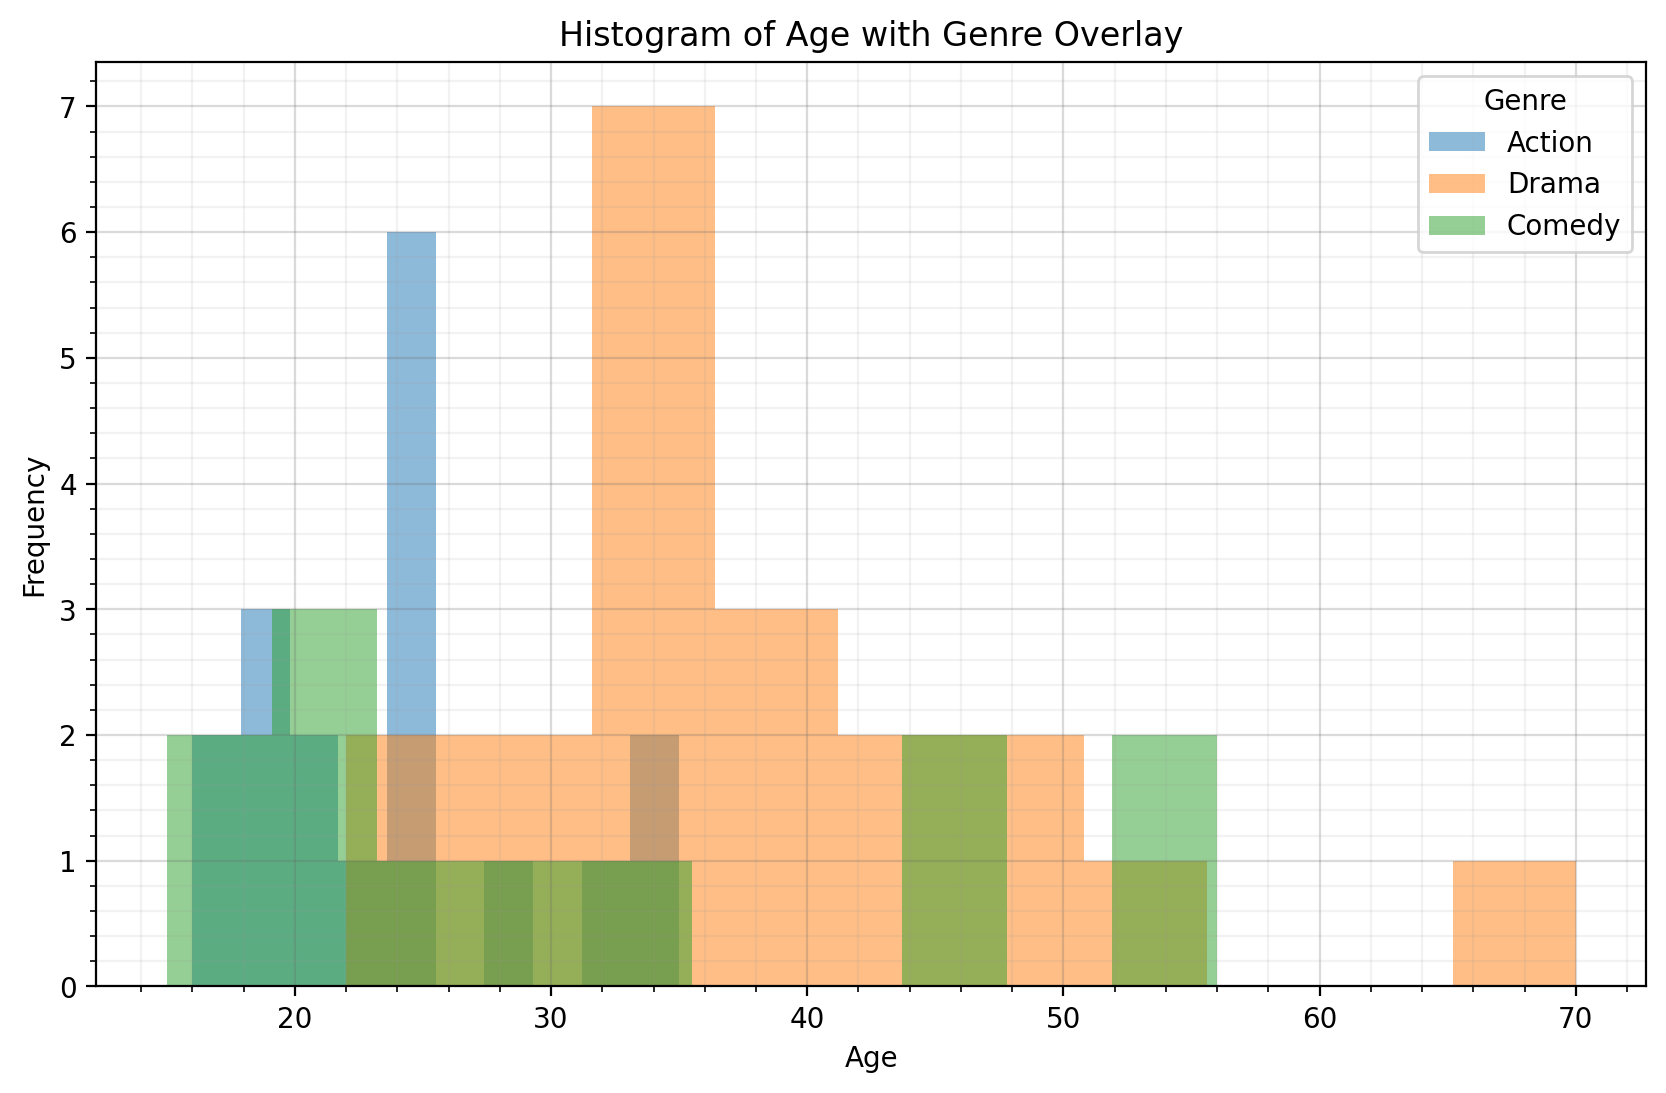

In [ ]:
genres = data['Genre'].unique()

# Set up the plot
plt.figure(figsize=(10, 6))

# Create bins
bins = 10

# Create histogram for each genre
for genre in genres:
    plt.hist(data[data['Genre'] == genre]['Age'], bins=bins, alpha=0.5, label=genre, stacked=True)

# labels and titles
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Histogram of Age with Genre Overlay')
plt.legend(title='Genre')

# Show the grid lines as dark grey lines
plt.grid(visible=True, which='major', color='#666666', linestyle='-', alpha=0.24)
# Show the minor grid lines with very faint and almost transparent grey lines
plt.minorticks_on()
plt.grid(visible=True, which='minor', color='#999999', linestyle='-', alpha=0.12)
plt.title('Histogram of Age with Genre Overlay')
plt.xlabel('Age');
plt.ylabel('Frequency');
plt.savefig("gdrive/MyDrive/WS4/ws4data/group_7_ws4_graph_3.jpg", bbox_inches='tight', dpi=300)
plt.show()


**Task:** Create a normalized histogram of `Age` (use bins=10) with `Genre` overlay (stacked).


Text(0.5, 0, 'Age')

Text(0, 0.5, 'Frequency')

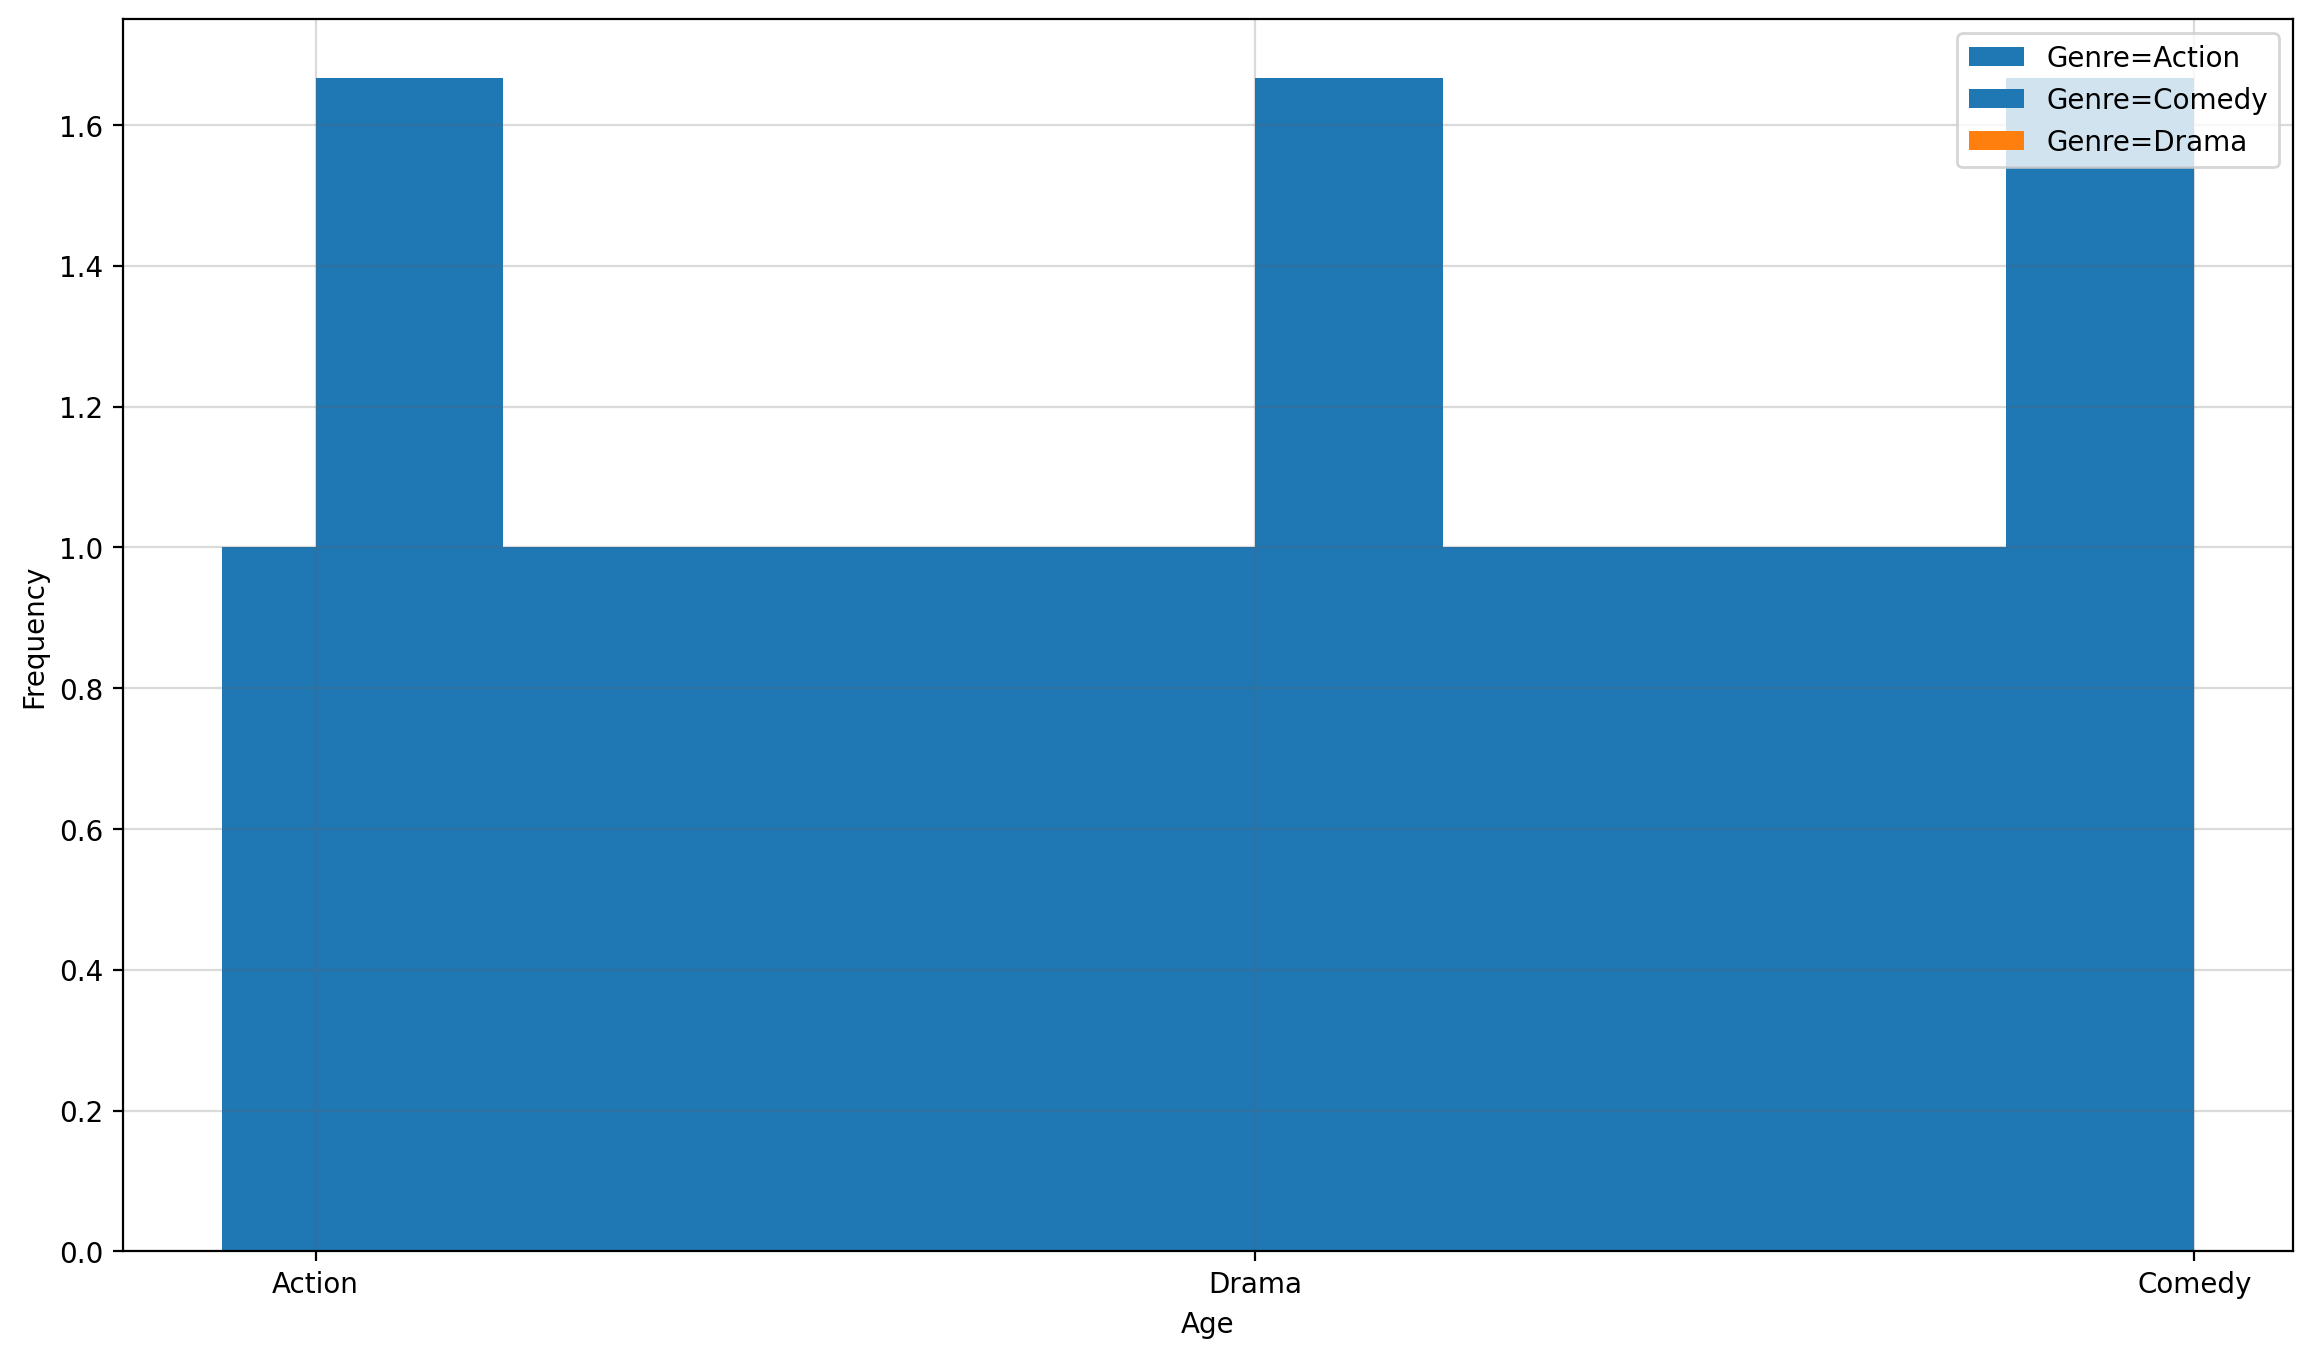

In [ ]:
fig=plt.figure(figsize=(14,8))
(n,bins,patches)=plt.hist(genres,bins=10,stacked=True,density=True)
n_table = np.column_stack((n[0], n[1], n[2]))

# Normalize each column (total across each bin)
total_per_bin = n_table.sum(axis=1) # sum across each bin (row-wise)
n_norm = n_table / total_per_bin[:, None]
ourbins=np.column_stack((bins[0:10],bins[1:11]))
p1=plt.bar(x=ourbins[:,0],height=n_norm[:,0],width=ourbins[:,1]-ourbins[:,0])
p2=plt.bar(x=ourbins[:,0],height=n_norm[:,1],width=ourbins[:,1]-ourbins[:,0],bottom=n_norm[:,0])
p2=plt.bar(x=ourbins[:,0],height=n_norm[:,2],width=ourbins[:,1]-ourbins[:,0],bottom=n_norm[:,0]+n_norm[:,1])

plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend(['Genre=Action','Genre=Comedy','Genre=Drama'])
plt.grid(which='major',color="#666666",linestyle='-',alpha=0.24)
plt.grid(which='minor',color="#999999",linestyle='-',alpha=0.12)
plt.show()


**Task:** Can you draw any significant conclusions from the previous three tasks?

In [ ]:
We see the choices in genre of movies in between different age group of individuals. We find that young individuals below 20 and between 20-30
mostly prefers action movies over movies of other genre, while the age group between 30-40 majorly prefers the drama genre of movies. Now after 40 the choices of people start to shift
and we find comedy genre dominating people's choices.


**Task:** Bin the Age variable using the below formula to create and add a new column called "age_binned".

Age_Binned={(1:under 20)
             (2:20 to 40)
             (3:Over 40)}

In [ ]:
# We put 40.01 as bin boundary to make 40 fall into 20to40 bin.
data['age_binned'] = pd.cut(x=data['Age'], bins = [0, 20, 40.01, 80], labels = ["Under 20", "20 to 40", "Over 40"], right = False) #new column
print(data[['Age','age_binned']].head)

<bound method NDFrame.head of     Age age_binned
0    25   20 to 40
1    33   20 to 40
2    20   20 to 40
3    70    Over 40
4    35   20 to 40
5    20   20 to 40
6    45    Over 40
7    25   20 to 40
8    21   20 to 40
9    40   20 to 40
10   22   20 to 40
11   22   20 to 40
12   46    Over 40
13   36   20 to 40
14   30   20 to 40
15   19   Under 20
16   35   20 to 40
17   16   Under 20
18   25   20 to 40
19   16   Under 20
20   52    Over 40
21   33   20 to 40
22   15   Under 20
23   35   20 to 40
24   16   Under 20
25   35   20 to 40
26   47    Over 40
27   52    Over 40
28   18   Under 20
29   25   20 to 40
30   56    Over 40
31   30   20 to 40
32   25   20 to 40
33   32   20 to 40
34   29   20 to 40
35   21   20 to 40
36   46    Over 40
37   38   20 to 40
38   35   20 to 40
39   19   Under 20
40   33   20 to 40
41   25   20 to 40
42   28   20 to 40
43   24   20 to 40
44   38   20 to 40
45   43    Over 40
46   35   20 to 40
47   47    Over 40
48   25   20 to 40
49   20   20 to 40>


**Task:** Create a horizontal bar graph of the `Agn_Binned` variable with a `Genre` overlay (stacked bar chart).

<Axes: title={'center': 'Bar Graph of Age(Binned) with Genre Overlay'}, ylabel='age_binned'>

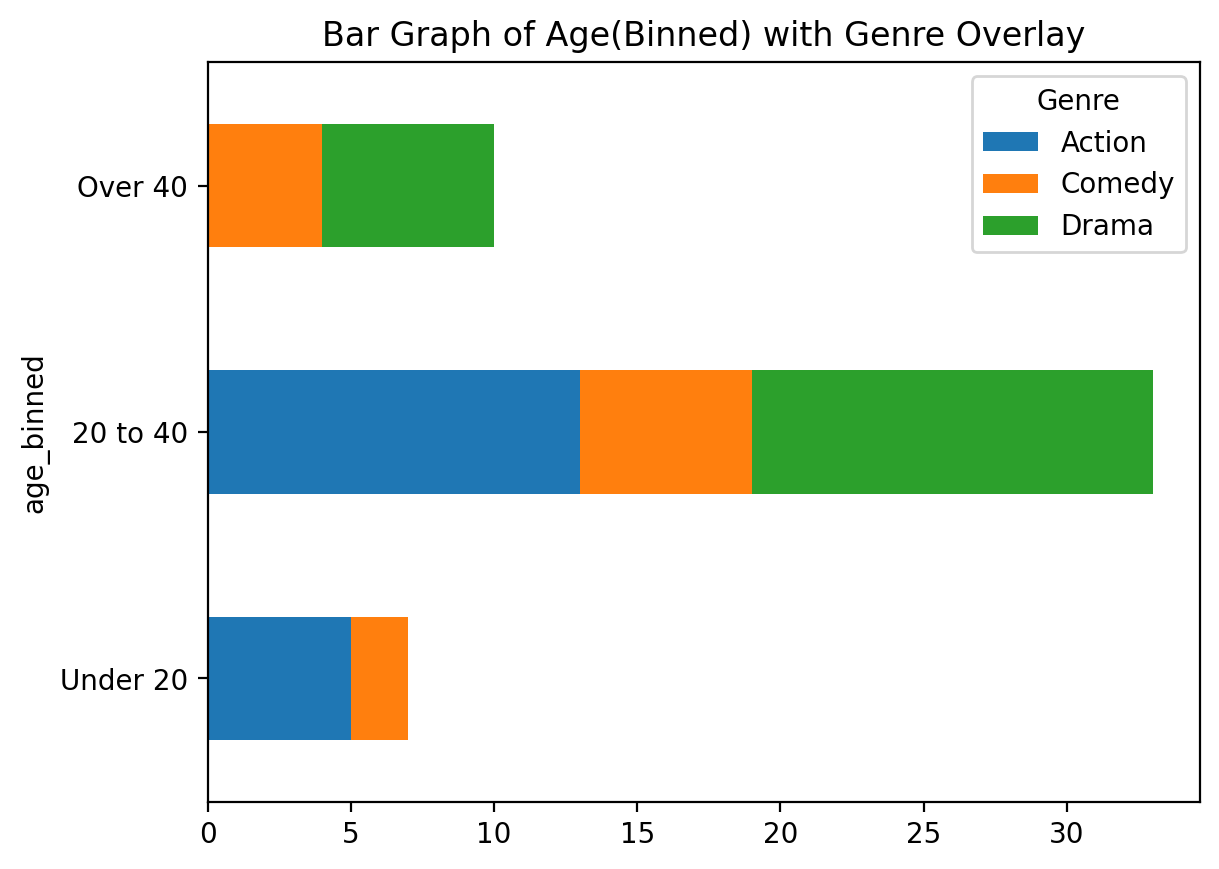

In [ ]:
crosstab = pd.crosstab(data['age_binned'], data['Genre']) #contingency table
crosstab.plot(kind='barh', stacked = True, title = 'Bar Graph of Age(Binned) with Genre Overlay')
plt.savefig("gdrive/MyDrive/WS4/ws4data/group_7_ws4_graph_5.jpg", bbox_inches='tight', dpi=300)


**Task:** Can you draw any significant conclusions from the previous two steps?

In [ ]:
The age group from which maximum number of individual go to watch movies is between 20 to 40. Also
the choices of movies genre based on age group is different, while between 20-40 there is less preference for the comedy genre and almost
equal preference for the drama and action movies. Individuals under 20 dont prefere drama at all and majority of them only likes to watch
action movie with some also choosing comedy. And in the age group above 40, people dont like to watch action movies. They mostly
prefer drama and a few percent of individual also prefer comedy but there is not even a single individual in this age group that
prefers action over the other two genre.